In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Set visualization style
sns.set(style="whitegrid")

In [7]:
df = pd.read_csv(r"D:\daily_food_nutrition_dataset.csv", on_bad_lines='skip')

In [23]:
print("--- First 5 Rows ---")
display(df.head())

--- First 5 Rows ---


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


In [24]:
print("\n--- Last 5 Rows ---")
display(df.tail())


--- Last 5 Rows ---


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
640,Pickled Cucumber (1/4 cup),Vegetable,10,0.5,2.0,0.0,1.0,1.0,300,0,Dinner,0
641,Fattoush Salad (1.5 cups),Meal/Vegetarian,250,5.0,25.0,15.0,6.0,5.0,500,0,Lunch,0
642,Fried Pita (1/2 pita in salad),Grain,80,2.0,12.0,3.0,1.0,0.5,150,0,Lunch,0
643,Sumac (1/2 tsp dressing),Condiment,5,0.1,1.0,0.2,0.5,0.0,1,0,Lunch,0
644,Pomegranate Molasses (1 tsp),Condiment,15,0.0,4.0,0.0,0.0,4.0,0,0,Lunch,0


In [26]:
print("\n--- Statistical Description ---")
display(df.describe())


--- Statistical Description ---


,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Water_Intake (ml)
count,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000,645.000000
mean,146.294574,6.300620,15.435194,6.469612,1.702481,5.294264,246.331783,20.482171,68.700775
std,139.984360,8.782683,16.349230,8.142916,2.121275,8.537343,308.472431,43.560072,137.077115
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.500000,1.300000,0.200000,0.000000,0.400000,5.000000,0.000000,0.000000
50%,105.000000,2.700000,9.200000,3.000000,1.000000,2.000000,120.000000,0.000000,0.000000
75%,200.000000,7.000000,27.000000,10.000000,3.000000,6.000000,350.000000,25.000000,0.000000
max,680.000000,45.000000,70.000000,40.000000,14.000000,60.000000,1580.000000,450.000000,500.000000


In [25]:
print("--- Dataset Info ---")
df.info()

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 645 entries, 0 to 644
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Food_Item          645 non-null    object 
 1   Category           645 non-null    object 
 2   Calories (kcal)    645 non-null    int64  
 3   Protein (g)        645 non-null    float64
 4   Carbohydrates (g)  645 non-null    float64
 5   Fat (g)            645 non-null    float64
 6   Fiber (g)          645 non-null    float64
 7   Sugars (g)         645 non-null    float64
 8   Sodium (mg)        645 non-null    int64  
 9   Cholesterol (mg)   645 non-null    int64  
 10  Meal_Type          645 non-null    object 
 11  Water_Intake (ml)  645 non-null    int64  
dtypes: float64(5), int64(4), object(3)
memory usage: 60.6+ KB


In [12]:
# Check for null values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Food_Item            0
Category             0
Calories (kcal)      0
Protein (g)          0
Carbohydrates (g)    0
Fat (g)              0
Fiber (g)            0
Sugars (g)           0
Sodium (mg)          0
Cholesterol (mg)     0
Meal_Type            0
Water_Intake (ml)    0
dtype: int64


In [13]:
# Fill missing numeric values with the column mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [14]:
# Drop rows where critical categorical data might be missing
df.dropna(inplace=True)
print("\nNull values handled.")


Null values handled.


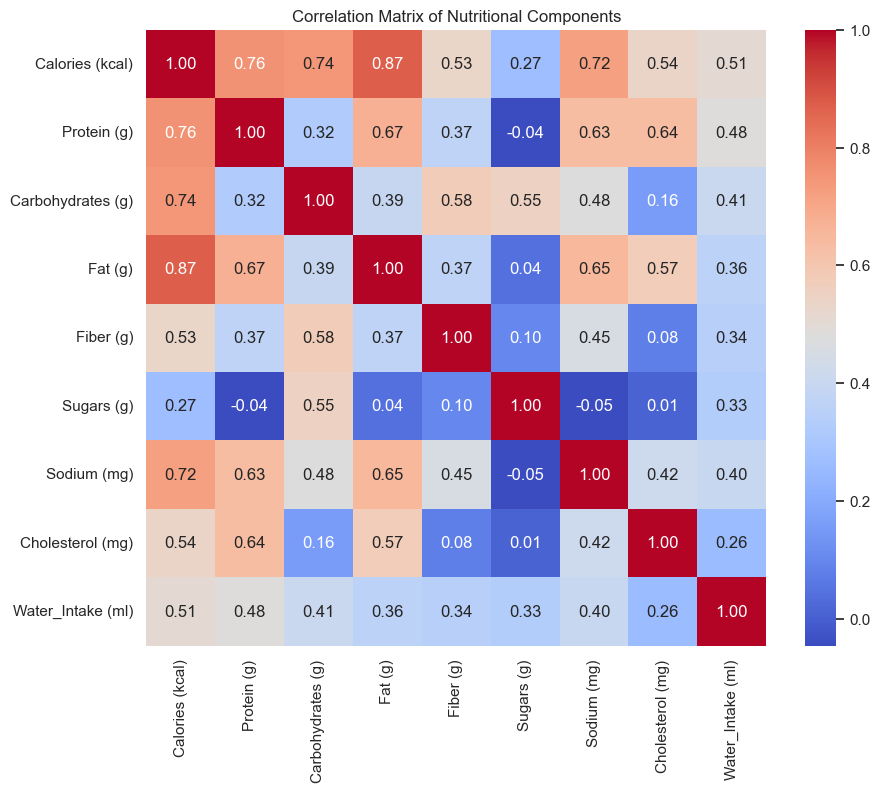

In [15]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Nutritional Components")
plt.show()

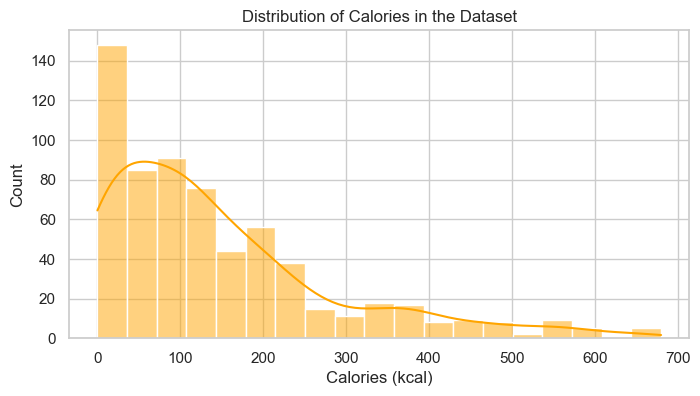

In [16]:
# Distribution of Calories
plt.figure(figsize=(8, 4))
sns.histplot(df['Calories (kcal)'], kde=True, color='orange')
plt.title("Distribution of Calories in the Dataset")
plt.show()

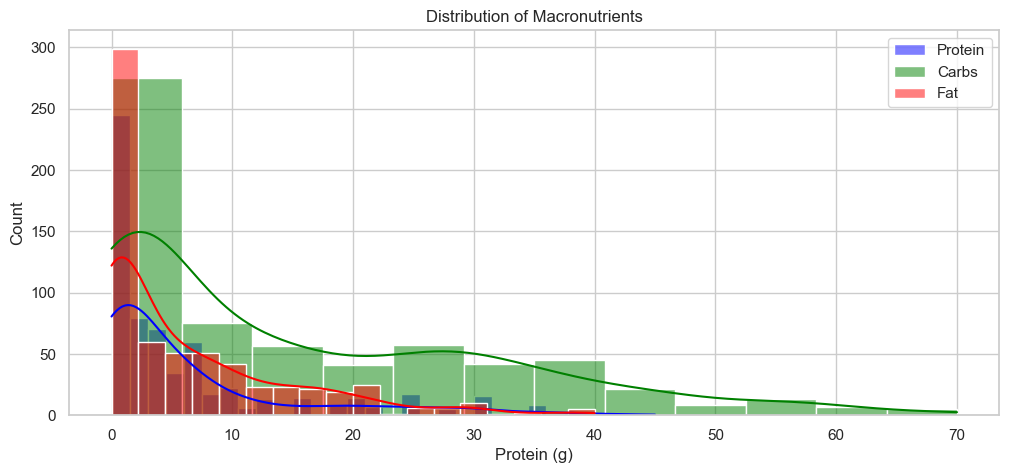

In [20]:
# Visualize the distribution of Fat, Carbs, and Protein
plt.figure(figsize=(12, 5))
sns.histplot(df['Protein (g)'], color='blue', label='Protein', kde=True)
sns.histplot(df['Carbohydrates (g)'], color='green', label='Carbs', kde=True)
sns.histplot(df['Fat (g)'], color='red', label='Fat', kde=True)
plt.legend()
plt.title("Distribution of Macronutrients")
plt.show()

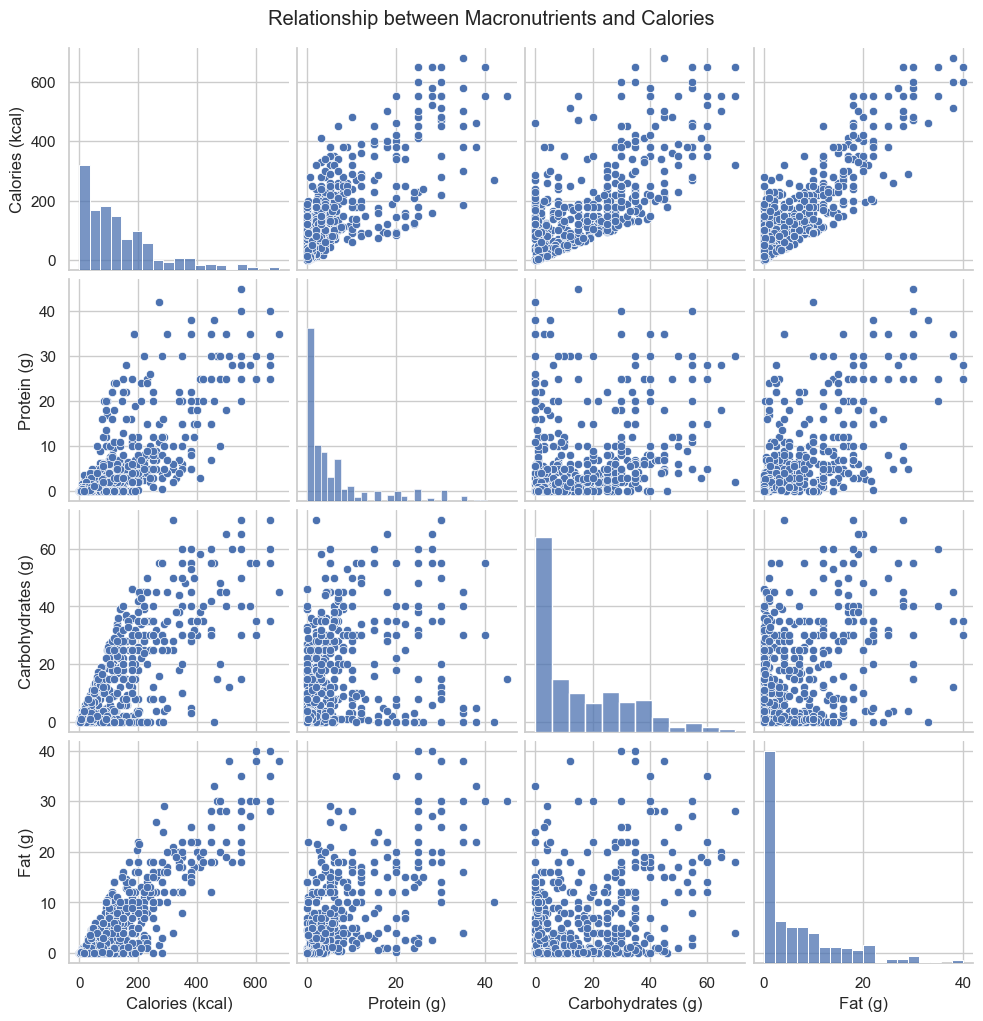

In [21]:
# Create a pairplot to see relationships between all nutritional components
sns.pairplot(df[['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 'Fat (g)']])
plt.suptitle("Relationship between Macronutrients and Calories", y=1.02)
plt.show()

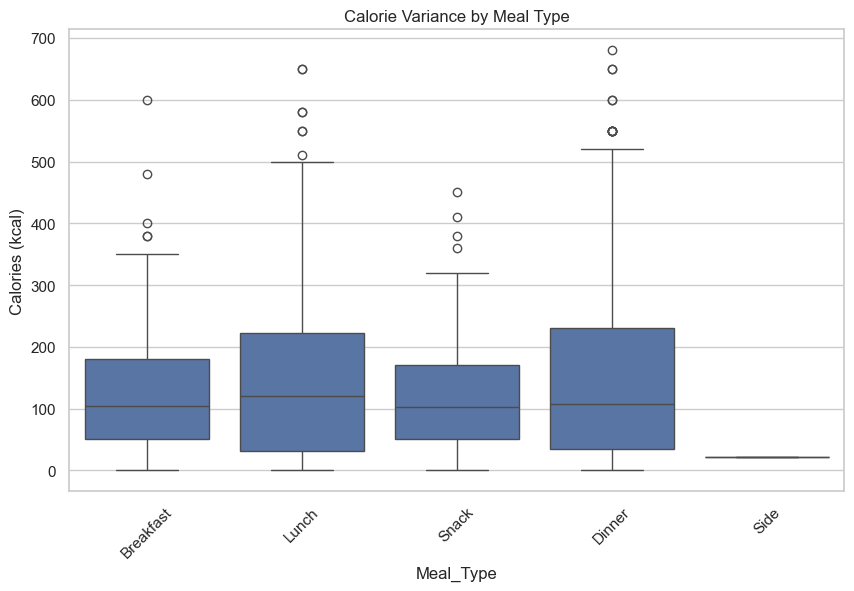

In [22]:
# Compare calories across different meal types
plt.figure(figsize=(10, 6))
sns.boxplot(x='Meal_Type', y='Calories (kcal)', data=df)
plt.title("Calorie Variance by Meal Type")
plt.xticks(rotation=45)
plt.show()

In [17]:
# Selecting features (X) and target (y)
X = df[['Protein (g)', 'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)']]
y = df['Calories (kcal)']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Model Evaluation
print(f"R-squared Score: {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")

R-squared Score: 0.98
Mean Squared Error: 390.77


In [19]:
# Comparing Actual vs Predicted
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\n--- Model Prediction Comparison (Sample) ---")
display(comparison_df.head(10))

print("\n--- Conclusion ---")
print("The Linear Regression model successfully predicts calorie content based on macronutrients.")
print("The R-squared score indicates how well the variance in calories is explained by the protein, carbs, fat, and fiber.")


--- Model Prediction Comparison (Sample) ---


,Actual,Predicted
632,2,5.184779
592,2,5.184779
599,3,4.882300
291,180,177.077094
72,103,103.189952
643,5,8.094985
597,97,2.736271
396,6,8.693451
511,180,83.802146
174,150,146.969285



--- Conclusion ---
The Linear Regression model successfully predicts calorie content based on macronutrients.
The R-squared score indicates how well the variance in calories is explained by the protein, carbs, fat, and fiber.
